In [64]:
from netCDF4 import Dataset
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from math import radians, cos, sin, asin, sqrt
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

In [ ]:
# ------------------------------------------------------
# Notebook: This script demonstrates how to link tracks to netcdf and geoTiff files
# ------------------------------------------------------

In [53]:
filepaths = ['C:\\code\\CLUES\\data\\reanalysis-era5-land\\2m_dewpoint_temperature\\2021.nc',
            'C:\\code\\CLUES\\data\\reanalysis-era5-land\\2m_dewpoint_temperature\\2022.nc',
            'C:\\code\\CLUES\\data\\reanalysis-era5-land\\2m_dewpoint_temperature\\2023.nc']
# Open all files as a single xarray dataset (if same variables/dimensions)
ds = xr.open_mfdataset(filepaths, combine='by_coords')
lat = ds.variables["latitude"][:]
lon = ds.variables["longitude"][:]

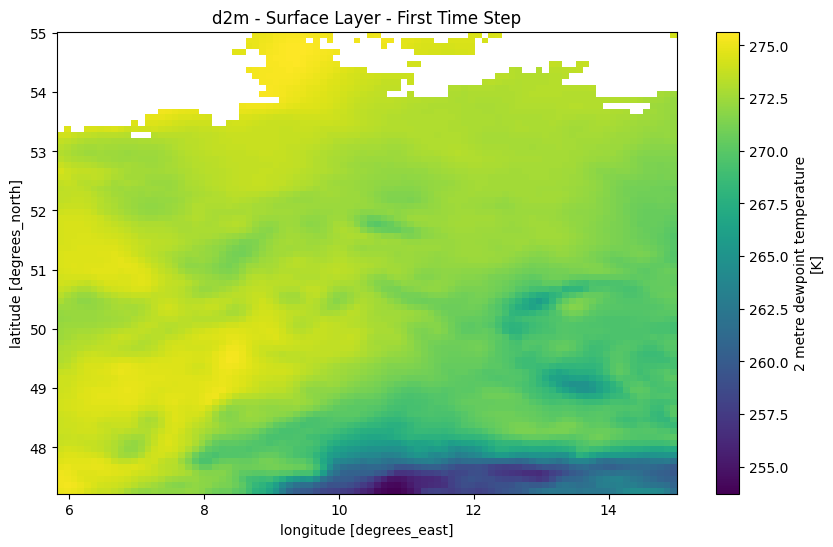

In [57]:
# Select variable
var_name = 'd2m'

# If there's a vertical dimension, pick the surface layer
if 'level' in ds[var_name].dims:
    layer = ds[var_name].isel(valid_time=0, time=0)  # first level, first time
else:
    layer = ds[var_name].isel(valid_time=0)           # first time

# Plot
plt.figure(figsize=(10,6))
layer.plot(cmap='viridis')  # xarray plotting handles lat/lon coordinates
plt.title(f"{var_name} - Surface Layer - First Time Step")
plt.show()

In [58]:
# ------------------------------------------------------
# Genarate random walk track within bounding box of 
# lat/lon data as dumy track
# ------------------------------------------------------

# ------------------------------------------------------
# Move point by distance + bearing
# ------------------------------------------------------
def move_point(lat, lon, distance_m, bearing_deg):
    R = 6371000  # Earth radius (m)
    br = radians(bearing_deg)

    lat1 = radians(lat)
    lon1 = radians(lon)

    lat2 = np.arcsin(sin(lat1)*cos(distance_m/R) +
                     cos(lat1)*sin(distance_m/R)*cos(br))

    lon2 = lon1 + np.arctan2(
        sin(br)*sin(distance_m/R)*cos(lat1),
        cos(distance_m/R)-sin(lat1)*sin(lat2)
    )

    return np.degrees(lat2), np.degrees(lon2)

# ------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------
n_points = 300          # length of track
max_dt_seconds = 60*60*72         # timestep
max_speed = 0.5         # m/s (example)
max_step = max_speed * dt_seconds  # max distance per step

# Bounds from your NetCDF data
lat_min, lat_max = np.min(lat), np.max(lat)
lon_min, lon_max = np.min(lon), np.max(lon)

# ------------------------------------------------------
# GENERATE TRACK
# ------------------------------------------------------
timestamps = []
lat_track = []
lon_track = []

cur_time = datetime(2021, 1, 1, 0, 0, 0)

# First point: random
cur_lat = np.random.uniform(lat_min, lat_max)
cur_lon = np.random.uniform(lon_min, lon_max)

lat_track.append(cur_lat)
lon_track.append(cur_lon)
timestamps.append(cur_time)

# Random-walk sequence
for i in range(1, n_points):
    # Random movement distance (0 to max_step)
    dist = np.random.uniform(0, max_step)
    # Random bearing 0–360°
    bearing = np.random.uniform(0, 360)

    # Compute new position
    new_lat, new_lon = move_point(cur_lat, cur_lon, dist, bearing)

    # Stay inside bounding box:
    new_lat = float(np.clip(new_lat, lat_min, lat_max))
    new_lon = float(np.clip(new_lon, lon_min, lon_max))

    # Append
    cur_lat, cur_lon = new_lat, new_lon
    lat_track.append(cur_lat)
    lon_track.append(cur_lon)
    timestamps.append(cur_time + timedelta(seconds=i*dt_seconds))

# Assemble in a DataFrame
track = pd.DataFrame({
    "time": timestamps,
    "lat": lat_track,
    "lon": lon_track
})

#track['time'] = np.array(track['time'], dtype='datetime64[ns]')

print(track)


                   time        lat        lon
0   2021-01-01 00:00:00  50.385652   9.115485
1   2021-01-02 03:00:00  50.368148   9.099302
2   2021-01-03 06:00:00  50.264715   9.243054
3   2021-01-04 09:00:00  50.190341   9.722630
4   2021-01-05 12:00:00  50.288834   9.758080
..                  ...        ...        ...
295 2021-11-28 21:00:00  49.111880  14.172406
296 2021-11-30 00:00:00  48.996551  14.198516
297 2021-12-01 03:00:00  49.345982  14.326304
298 2021-12-02 06:00:00  49.450914  14.462725
299 2021-12-03 09:00:00  49.508871  14.447586

[300 rows x 3 columns]


In [61]:
#------------------------------------------------------
# EXTRACT VARIABLE VALUES ALONG TRACK
#------------------------------------------------------

d2m_values = []

for t, la, lo in zip(track['time'], track['lat'], track['lon']):
    val = ds[var_name].interp(
        valid_time=np.datetime64(t),
        latitude=la,
        longitude=lo,
        method='nearest'
    )
    d2m_values.append(val.values)

track['d2m'] = d2m_values
track

,time,lat,lon,d2m
0,2021-01-01 00:00:00,50.385652,9.115485,273.726
1,2021-01-02 03:00:00,50.368148,9.099302,272.53247
2,2021-01-03 06:00:00,50.264715,9.243054,271.25342
3,2021-01-04 09:00:00,50.190341,9.722630,271.56927
4,2021-01-05 12:00:00,50.288834,9.758080,271.4336
...,...,...,...,...
295,2021-11-28 21:00:00,49.111880,14.172406,268.35083
296,2021-11-30 00:00:00,48.996551,14.198516,268.52808
297,2021-12-01 03:00:00,49.345982,14.326304,274.05786
298,2021-12-02 06:00:00,49.450914,14.462725,274.13257


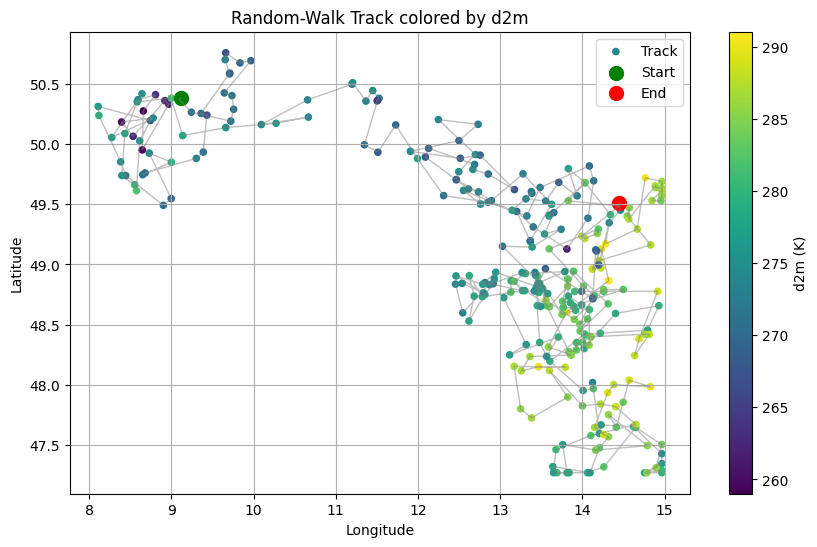

In [62]:
#------------------------------------------------------
# PLOTTING THE TRACK COLORED BY d2m
#------------------------------------------------------

plt.figure(figsize=(10, 6))

# Scatter points color-coded by d2m
sc = plt.scatter(
    track['lon'], 
    track['lat'], 
    c=track['d2m'],        # color by d2m
    cmap='viridis',        # choose a colormap
    s=20,                  # marker size
    label='Track'
)

# Optionally connect points with a line
plt.plot(track['lon'], track['lat'], color='gray', alpha=0.5, linewidth=1)

# Start and end points
plt.scatter(track['lon'].iloc[0], track['lat'].iloc[0], color='green', s=100, label='Start')
plt.scatter(track['lon'].iloc[-1], track['lat'].iloc[-1], color='red', s=100, label='End')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Random-Walk Track colored by d2m")
plt.grid(True)
plt.legend()

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label("d2m (K)")

plt.show()


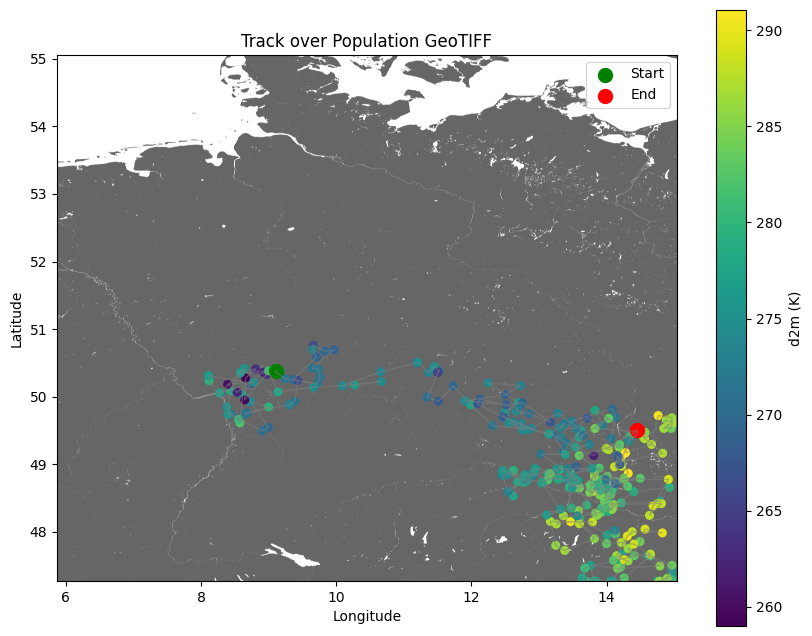

In [66]:
#------------------------------------------------------
# Step 1: Load the GeoTIFF
#------------------------------------------------------

# Load GeoTIFF
tif_path = r'C:\code\CLUES\data\WordPop\people_per_pixel\2018.tif'
dataset = rasterio.open(tif_path)

# Read the first band
data = dataset.read(1)  # 2D array

#------------------------------------------------------
# Step 2: Prepare coordinates
#------------------------------------------------------

transform = dataset.transform
height, width = data.shape

# Create longitude and latitude arrays
cols, rows = np.meshgrid(np.arange(width), np.arange(height))
lons, lats = rasterio.transform.xy(transform, rows, cols)
lons = np.array(lons)
lats = np.array(lats)

#------------------------------------------------------
# Step 3: Plot GeoTIFF and track
#------------------------------------------------------

plt.figure(figsize=(10, 8))

# Plot the GeoTIFF
plt.imshow(
    data, 
    extent=(lons.min(), lons.max(), lats.min(), lats.max()),
    origin='upper',
    cmap='Greys',  # or another colormap
    alpha=0.6
)

# Plot the track colored by d2m
sc = plt.scatter(
    track['lon'], 
    track['lat'], 
    c=track['d2m'], 
    cmap='viridis',
    s=30
)

# Optionally connect points
plt.plot(track['lon'], track['lat'], color='gray', alpha=0.5, linewidth=1)

# Start/end points
plt.scatter(track['lon'].iloc[0], track['lat'].iloc[0], color='green', s=100, label='Start')
plt.scatter(track['lon'].iloc[-1], track['lat'].iloc[-1], color='red', s=100, label='End')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Track over Population GeoTIFF")
plt.legend()
cbar = plt.colorbar(sc)
cbar.set_label("d2m (K)")

plt.show()

In [68]:
#------------------------------------------------------
# Step 4: Extract population values along the track
#------------------------------------------------------

# Create an empty list to hold values
pop_values = []

for lon, lat in zip(track['lon'], track['lat']):
    try:
        # Get row/col indices corresponding to lon/lat
        row, col = dataset.index(lon, lat)
        # Extract the value from the array
        val = data[row, col]
    except IndexError:
        # If the point is outside the raster, return NaN
        val = np.nan
    pop_values.append(val)

# Add to track DataFrame
track['population'] = pop_values

print(track.head())

                 time        lat       lon        d2m  population
0 2021-01-01 00:00:00  50.385652  9.115485    273.726    0.332832
1 2021-01-02 03:00:00  50.368148  9.099302  272.53247    0.240537
2 2021-01-03 06:00:00  50.264715  9.243054  271.25342    0.129384
3 2021-01-04 09:00:00  50.190341  9.722630  271.56927    0.000000
4 2021-01-05 12:00:00  50.288834  9.758080   271.4336    0.213982
